<a href="https://colab.research.google.com/github/HakumenWorld/data-science-2026/blob/main/Pertemuan11_Febi_Kristiana_240401010231.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pertemuan 11
# Aktivitas Hands-on: Segmentasi Pelanggan
**Mata Kuliah:** Pengantar Data Science  
**Pertemuan:** 11  
**Nama:** Febi Kristiana  
**NIM:** 240401010231

Notebook ini disusun mengikuti bagian **Aktivitas Hands-on** pada modul pertemuan 11.  
Jalankan sel secara berurutan dari atas ke bawah di Google Colab.

## Langkah 0 — Buat File Jupyter Notebook Baru
Nama file sesuai modul: `Pertemuan11_[Nama]_[NIM].ipynb`

Aktivitas membangun pipeline **segmentasi pelanggan** menggunakan K-Means, Metode Elbow,
Silhouette Score, visualisasi cluster, dan Hierarchical Clustering sebagai pembanding.

## Langkah 1 — Generate & Eksplorasi Dataset

Shape: (300, 4)


,pendapatan_tahunan,skor_belanja,usia
count,300.00,300.00,300.00
mean,69.96,53.23,42.07
std,33.82,27.41,13.59
min,14.28,4.10,18.00
25%,32.14,25.60,30.00
50%,70.84,55.11,43.00
75%,103.40,78.16,53.00
max,140.79,103.17,64.00


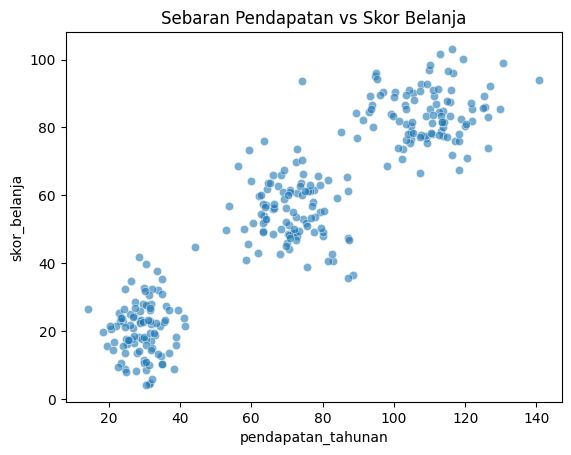

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

grp1 = np.random.normal([30, 20], [6, 8], (100, 2))   # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))  # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2)) # boros

data = np.vstack([grp1, grp2, grp3])
df = pd.DataFrame(data, columns=["pendapatan_tahunan", "skor_belanja"])
df["usia"] = np.random.randint(18, 65, len(df))
df["gender"] = np.random.choice(["L", "P"], len(df))

print("Shape:", df.shape)
display(df.describe().round(2))

sns.scatterplot(
    data=df,
    x="pendapatan_tahunan",
    y="skor_belanja",
    alpha=0.6
)
plt.title("Sebaran Pendapatan vs Skor Belanja")
plt.show()

## Langkah 2 — Preprocessing Data

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[["pendapatan_tahunan", "skor_belanja"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rata-rata setelah scaling:", X_scaled.mean(axis=0).round(3))
print("Std setelah scaling     :", X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [-0.  0.]
Std setelah scaling     : [1. 1.]


## Langkah 3 — Metode Elbow untuk Menentukan K

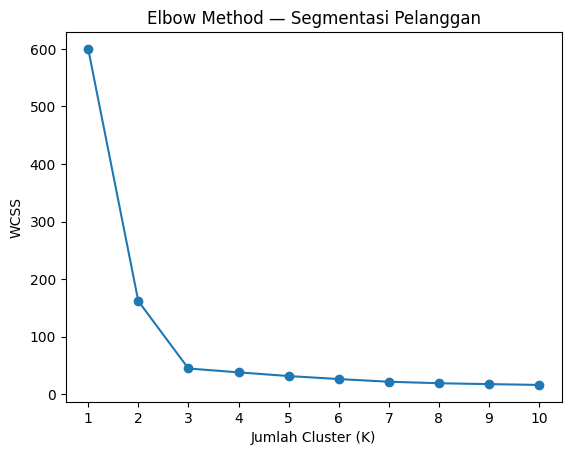

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    km = KMeans(
        n_clusters=k,
        random_state=42,
        init="k-means++",
        n_init=10
    )
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Segmentasi Pelanggan")
plt.xticks(range(1, 11))
plt.show()

**Interpretasi grafik Elbow:** cari titik ketika penurunan WCSS mulai melandai.
Dataset sintetis memang dibuat dengan tiga kelompok tersembunyi, sehingga periksa apakah
titik elbow terlihat di sekitar `K = 3`.

## Langkah 4 — Melatih Model K-Means

In [ ]:
from sklearn.metrics import silhouette_score

model = KMeans(
    n_clusters=3,
    random_state=42,
    init="k-means++",
    n_init=10
)
model.fit(X_scaled)

df["cluster"] = model.labels_

print(f"WCSS akhir      : {model.inertia_:.3f}")
print(f"Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}")

profil_cluster = df.groupby("cluster")[
    ["pendapatan_tahunan", "skor_belanja"]
].mean().round(2)

display(profil_cluster)

WCSS akhir      : 44.556
Silhouette Score: 0.695


,pendapatan_tahunan,skor_belanja
cluster,,
0,70.99,55.05
1,29.31,20.27
2,109.20,84.08


## Langkah 5 — Visualisasi Hasil Clustering

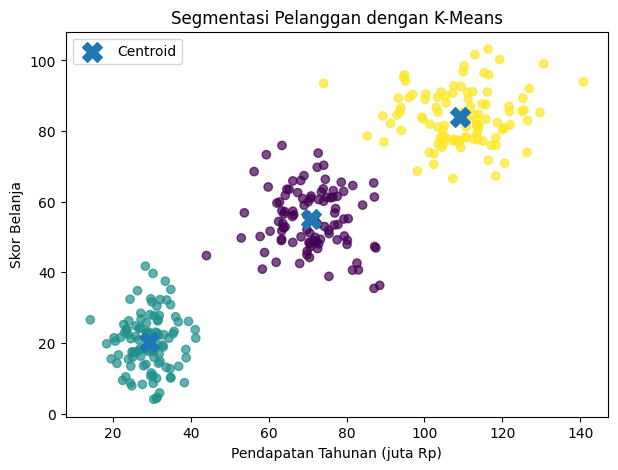

In [ ]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(
    df["pendapatan_tahunan"],
    df["skor_belanja"],
    c=df["cluster"],
    cmap="viridis",
    alpha=0.7
)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    label="Centroid"
)
plt.xlabel("Pendapatan Tahunan (juta Rp)")
plt.ylabel("Skor Belanja")
plt.title("Segmentasi Pelanggan dengan K-Means")
plt.legend()
plt.show()

In [ ]:
# Interpretasi otomatis berdasarkan rerata tiap cluster.
profil = df.groupby("cluster")[
    ["pendapatan_tahunan", "skor_belanja"]
].mean()

urutan = profil.mean(axis=1).sort_values().index.tolist()
label_segmen = {
    urutan[0]: "Hemat",
    urutan[1]: "Menengah",
    urutan[2]: "Boros/Premium"
}

print("Interpretasi cluster:")
for cluster_id in sorted(label_segmen):
    row = profil.loc[cluster_id]
    print(
        f"Cluster {cluster_id}: {label_segmen[cluster_id]} | "
        f"Pendapatan rata-rata={row['pendapatan_tahunan']:.2f}, "
        f"Skor belanja rata-rata={row['skor_belanja']:.2f}"
    )

Interpretasi cluster:
Cluster 0: Menengah | Pendapatan rata-rata=70.99, Skor belanja rata-rata=55.05
Cluster 1: Hemat | Pendapatan rata-rata=29.31, Skor belanja rata-rata=20.27
Cluster 2: Boros/Premium | Pendapatan rata-rata=109.20, Skor belanja rata-rata=84.08


## Langkah 6 — Hierarchical Clustering (Pembanding)

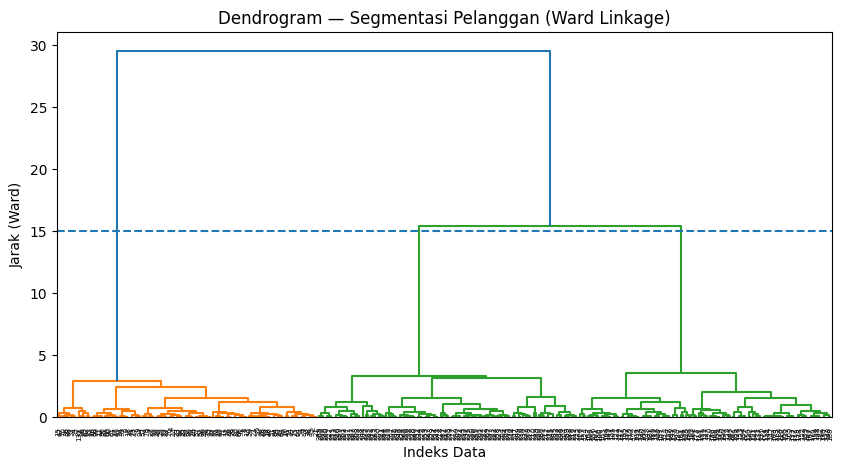

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram — Segmentasi Pelanggan (Ward Linkage)")
plt.xlabel("Indeks Data")
plt.ylabel("Jarak (Ward)")
plt.axhline(y=15, linestyle="--")
plt.show()

**Diskusi:** bandingkan jumlah cluster yang terlihat dari dendrogram dengan `K` optimal
pada Metode Elbow. Apabila keduanya sama atau mendekati, hasil segmentasi menjadi lebih
meyakinkan.

## Kesimpulan

Dari aktivitas hands-on ini, kita berhasil melakukan segmentasi pelanggan menggunakan algoritma K-Means dan Hierarchical Clustering.

**Temuan Utama:**
- Dengan Metode Elbow, kita dapat mengidentifikasi 3 cluster optimal, yang konsisten dengan data sintetis yang sengaja dibuat untuk memiliki tiga kelompok tersembunyi (hemat, menengah, boros/premium).
- Model K-Means dengan 3 cluster menunjukkan Silhouette Score yang baik, mengindikasikan segmentasi yang cukup jelas.
- Visualisasi K-Means dengan centroid menegaskan pemisahan yang jelas antara kelompok pelanggan berdasarkan pendapatan tahunan dan skor belanja.
- Hierarchical Clustering melalui dendrogram juga menunjukkan pembentukan 3 cluster yang koheren, memperkuat hasil dari K-Means.

**Pembelajaran:**
- Pentingnya *preprocessing* data (scaling) untuk algoritma berbasis jarak seperti K-Means.
- Metode Elbow dan Silhouette Score adalah alat yang efektif untuk menentukan jumlah cluster optimal.
- Interpretasi cluster didasarkan pada karakteristik rata-rata setiap segmen, membantu dalam memahami profil pelanggan.

**Keterbatasan & Pertanyaan Lanjutan:**
- Dataset yang digunakan adalah sintetis. Dalam skenario riil, data mungkin lebih kompleks dan memerlukan penanganan *outlier* atau fitur tambahan.
- Apakah ada fitur lain (misalnya, usia, gender, frekuensi belanja) yang dapat lebih memperkaya segmentasi?
- Bagaimana cara mengimplementasikan strategi pemasaran yang berbeda untuk setiap segmen pelanggan ini?